In [324]:
import numpy as np  
import matplotlib.pyplot as plt 
from random import sample
from sklearn.neighbors import KernelDensity
import scipy
import scipy.integrate as integrate
import astropy.visualization.hist

### Plot the resulting pdf of $M_{irr}$

First try an histogram with one the rules of thumb we've seen above.

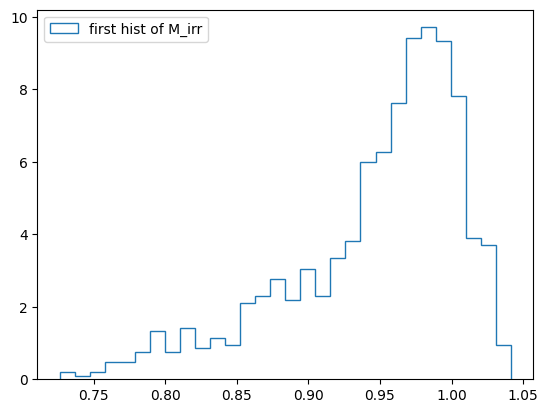

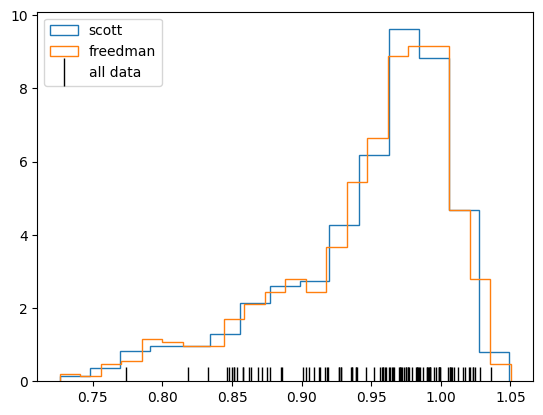

In [325]:
sigma=0.02
mu=1                    #mu (the mass in GR !) is only a scale factor 

chi = np.random.uniform(0,1,1000)   #chi distribution 
M=np.random.normal(mu,sigma,1000)    #M distribution

def f(X): 
    return np.sqrt((1+np.sqrt(1-X**2))/2)

M_irr=M*f(chi)

plt.hist(M_irr,30, histtype='step', density=True, label='first hist of M_irr')
plt.legend()
plt.show()

# rules of thumb of the bin's number
astropy.visualization.hist(M_irr, bins="scott", histtype="step",density=True, label='scott')
astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True, label='freedman')
plt.plot(M_irr[:100], 0*M_irr[:100], '|', color='k', markersize=20, label="all data");
plt.legend()
plt.show()

  

Same number of objects in each bin

11 35


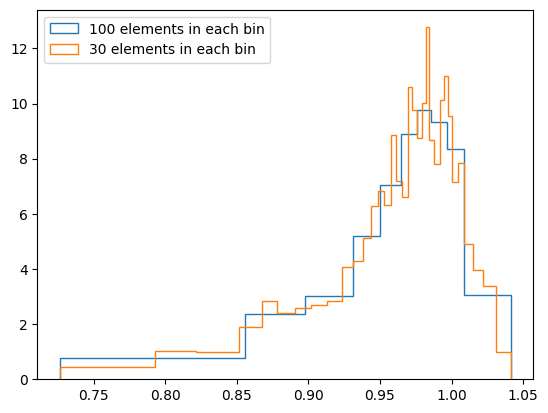

In [326]:
#selection of one element over 100 or 30 
#with append np.max bins array covers the entire interval--- this are the bin edges
bins100 = np.append(np.sort(M_irr)[::100], np.max(M_irr))   #100 in each bin 
bins30 = np.append(np.sort(M_irr)[::30], np.max(M_irr))     #30 elements in each bin
print(len(bins100),len(bins30))  

# passing a vector to bins= we give the bins edges 
plt.hist(M_irr, bins=bins100, density=True, histtype="step", label='100 elements in each bin') 
plt.hist(M_irr, bins=bins30, density=True, histtype="step", label='30 elements in each bin') #so bins ae smaller 
plt.legend()
plt.show()

## Using KDE with different bandwidth

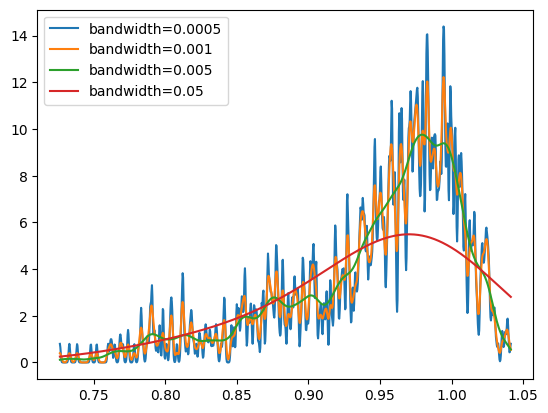

In [327]:
xgrid = np.linspace(M_irr.min(),M_irr.max(),1000) #x of KDE 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):

    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

bands = [0.0005, 0.001, 0.005, 0.05]
PDFmir = [kde_sklearn(M_irr,bandwidth=i,kernel="gaussian") for i in bands]
for i in range(len(bands)):
    plt.plot(xgrid, PDFmir[i], label=f'bandwidth={bands[i]}')
plt.legend()
plt.show()


### Pdf of $M_{irr}$
with samples it is simply the product without computing the analytic result 

In [328]:
#these lines are for the anaitical result

def f_pdf(f):                               #analitical pdf of chi  (from pen and paper)
    return 2*(2*f**2-1)/np.sqrt(1-f**2)

def to_int(f,Mirr,sigma):                                                   #integrate in f and Mirr is a parameter and also sigma 
    return np.exp(-(Mirr/f-mu)**2/(2*sigma**2))*f_pdf(f)/2/f

def Mirr_pdf(Mirr,sigma):                                                                      
    integral=integrate.quad(to_int,0.71,1, args=(Mirr,sigma,))  #integrate from 0.71 to 1 (the range of f)
    return integral[0]*np.sqrt(2/np.pi)/sigma                         #only the result of integral and not the error 


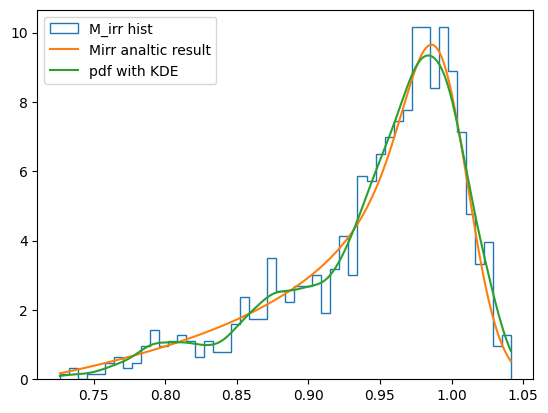

In [329]:
Mirrmin=np.min(M_irr)
Mirrmax=np.max(M_irr) 

xgrid3 = np.linspace(Mirrmin,Mirrmax,1000)    
s = [Mirr_pdf(Mirr,sigma) for Mirr in xgrid3]                           #because integrate.quad accept only scalar

plt.hist(M_irr,bins=50, histtype='step', density=True, label='M_irr hist')
plt.plot(xgrid3,s, label='Mirr analtic result')
PDFmir = kde_sklearn(M_irr,bandwidth=0.01,kernel="gaussian")
plt.plot(xgrid3, PDFmir, label='pdf with KDE')

plt.legend(loc='upper left')
plt.show() 

### Pdf of $f(\chi^2)$

Plotting with the histogram, KDE and analitic result 

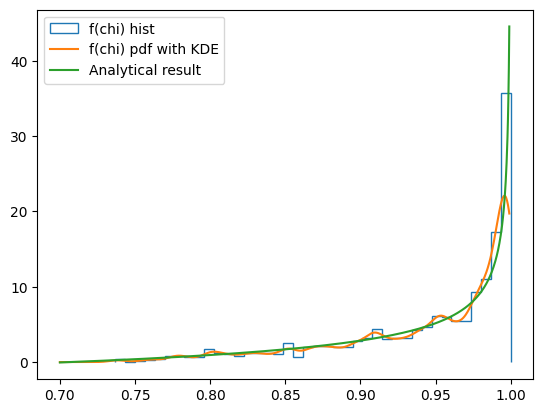

In [330]:
xgrid2 = np.linspace(0.7,0.999,1000) #at 1 it goes to infinity

plt.hist(f(chi),bins=40, histtype='step', density=True, label='f(chi) hist') 

def kde_sklearn2(data, bandwidth = 1.0, kernel="linear"):

    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid2[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFf = kde_sklearn2(f(chi),bandwidth=0.005,kernel="gaussian")
plt.plot(xgrid2,PDFf, label='f(chi) pdf with KDE')
plt.plot(xgrid2, f_pdf(xgrid2), label='Analytical result')
plt.legend();

In [ ]:
minf=np.min(f(chi))
maxf=np.max(f(chi)) 
nor=integrate.quad(f_pdf,minf,maxf)                 #normalization of the pdf 
nor

(0.9999935981320384, 1.0679145456826689e-08)

In [331]:
#function of M_irr given different sigma (everything in a function)

def M_Mirr(scale):
    M=np.random.normal(loc=1,scale=scale,size=1000)
    chi = np.random.uniform(0,1,1000)
    m = f(chi)
    return(m*M)

Plot for small sigma

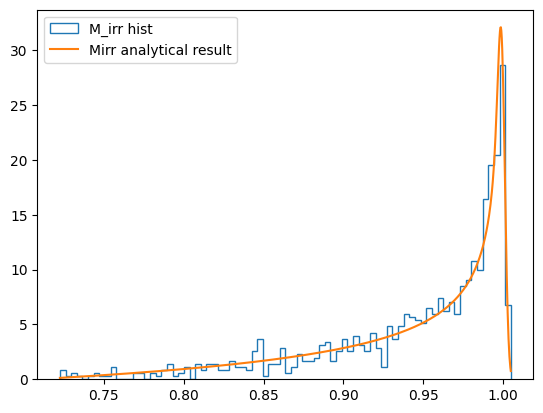

In [332]:
sigma1=0.002
  
M_irr=M_Mirr(sigma1)
x1 =np.linspace(np.min(M_irr),np.max(M_irr),1000) 

M_analytic = [Mirr_pdf(Mirr,sigma1) for Mirr in x1]
plt.hist(M_irr, bins=80, histtype='step', density=True, label='M_irr hist')
plt.plot(x1, M_analytic, label='Mirr analytical result')

plt.legend();

plot for big sigma

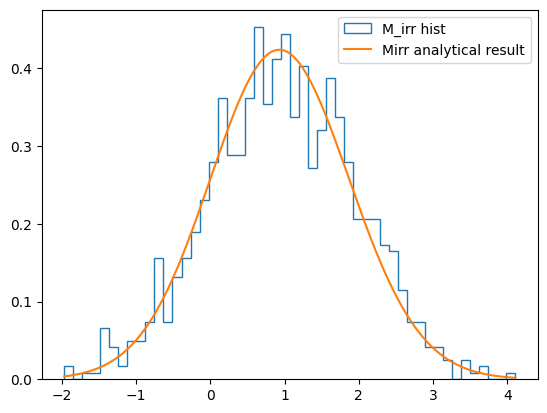

In [333]:
sigma2=1
M_irr=M_Mirr(sigma2)
x2 = np.linspace(np.min(M_irr),np.max(M_irr),1000) 

M_analytic = [Mirr_pdf(Mirr,sigma2) for Mirr in x2]
plt.hist(M_irr, bins=50, histtype='step', density=True, label='M_irr hist')
plt.plot(x2, M_analytic, label='Mirr analytical result')

plt.legend();

## Ks TEST Comparison with different $\sigma$

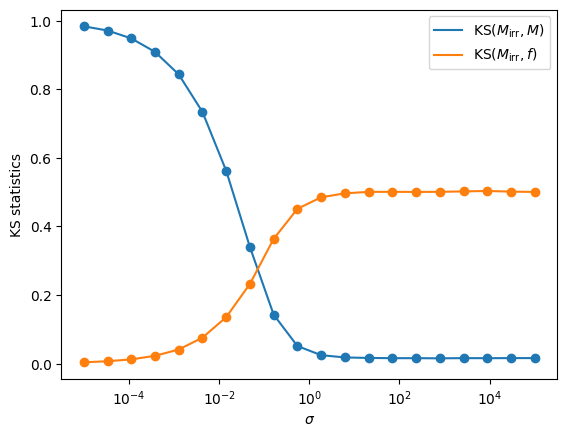

In [334]:
scales= np.logspace(-5,5,20) #different sigmas

ksM=[]              #KS test between M and M*f (Mirr)
ksf = []            #KS test between f and M*f (Mirr)

N=100000
chi = np.random.uniform(0,1,N)

for scale in scales:

    M=np.random.normal(loc=1,scale=scale,size=N)

    ksM.append(scipy.stats.ks_2samp(M, M*f(chi)).statistic)
    ksf.append(scipy.stats.ks_2samp(f(chi), M*f(chi)).statistic)

ksM= np.array(ksM)
ksf= np.array(ksf)

plt.plot(scales,ksM,label="KS$(M_{\\rm irr}, M)$")
plt.plot(scales,ksf,label="KS$(M_{\\rm irr}, f)$")
plt.scatter(scales,ksM)
plt.scatter(scales,ksf)
plt.semilogx()
plt.xlabel("$\sigma$")
plt.ylabel('KS statistics')
plt.legend();